In [1]:
import os
os.chdir("./..")

from models.ADR import ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR-Austria.yaml")
model_fit = ADR(config)
model_fit.load_state_dict(torch.load(r"/project/p1364-25-2/checkpoints/PV-PIML/ADR_Hybrid_Austria/epoch=15-step=16000.ckpt", weights_only=False)["state_dict"])

<All keys matched successfully>

In [2]:
data = model_fit.model.site_params.weight.data

data.shape

for variable in range(0, data.shape[1]):
    print(f"Variable {model_fit.model.param_names[variable]}:")
    print(f"Mean: {data[:, variable].mean():.4f}", f"\tMin: {data[:, variable].min():.4f}", f"\tMax: {data[:, variable].max():.4f}")
    print(" ")

Variable albedo:
Mean: -0.0021 	Min: -1.3201 	Max: 2.1246
 
Variable u0:
Mean: 0.0011 	Min: -1.3508 	Max: 1.1821
 
Variable u1:
Mean: -0.0050 	Min: -2.2389 	Max: 0.5089
 
Variable k_a:
Mean: -0.0009 	Min: -1.0084 	Max: 0.3106
 
Variable k_d:
Mean: -0.0003 	Min: -0.6228 	Max: 0.7937
 
Variable tc_d:
Mean: -0.0003 	Min: -0.5622 	Max: 0.5907
 
Variable k_rs:
Mean: 0.0010 	Min: -0.6890 	Max: 0.4026
 
Variable k_rsh:
Mean: 0.0005 	Min: -0.8088 	Max: 0.5590
 


In [3]:
data = model_fit.model.parameters()

for name, param in model_fit.model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

albedo_common tensor(-1.6413)
u0_common tensor(24.9823)
u1_common tensor(4.3444)
k_a_common tensor(0.3086)
k_d_common tensor(0.3374)
tc_d_common tensor(0.1694)
k_rs_common tensor(-0.3425)
k_rsh_common tensor(-0.9718)
site_params.weight tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [4]:
from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"/project/p1364-25-2/datasets/pv/processed/nwp_0h", previous_days=0, split="test", countries=["Austria"])

Text(0.5, 1.0, 'Austria 44740: 2023-06-29')

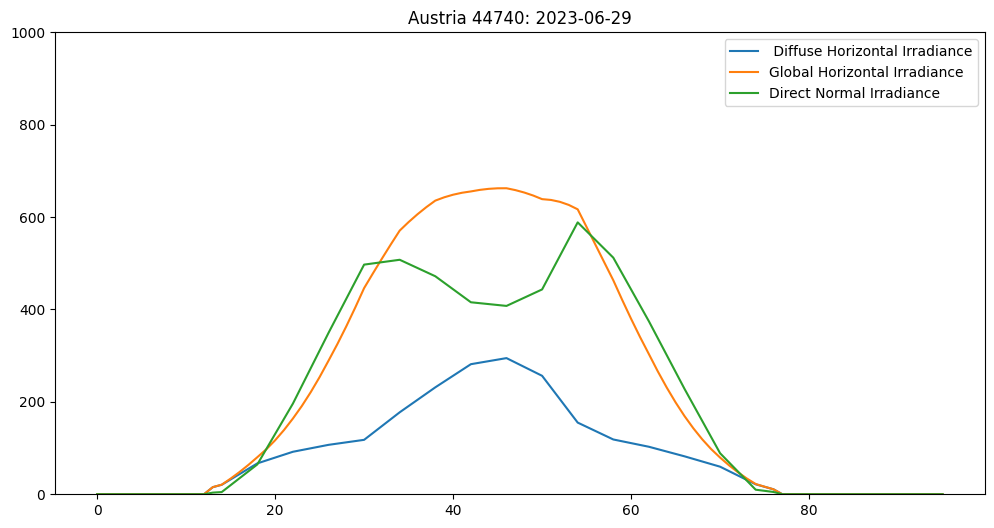

In [5]:
import matplotlib.pyplot as plt
from numpy import random

idx = random.randint(0, len(ds))

plt.figure(figsize=(12, 6))
plt.plot(ds[idx][0]["dhi"])
plt.plot(ds[idx][0]["ghi"])
plt.plot(ds[idx][0]["dni"])
plt.legend([" Diffuse Horizontal Irradiance", "Global Horizontal Irradiance", "Direct Normal Irradiance"])

plt.ylim(0, 1000)

plt.title(f"{ds[idx][2]['country']} {ds[idx][2]['installation']}: {ds[idx][2]['date']}")

/tmp/ipykernel_1576503/1236258792.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.cos(ds[idx][0]["solar_zenith"]) * ds[idx][0]["dni"] + ds[idx][0]["dhi"], label="Calculated GHI (DNI * cos(zenith) + DHI)")


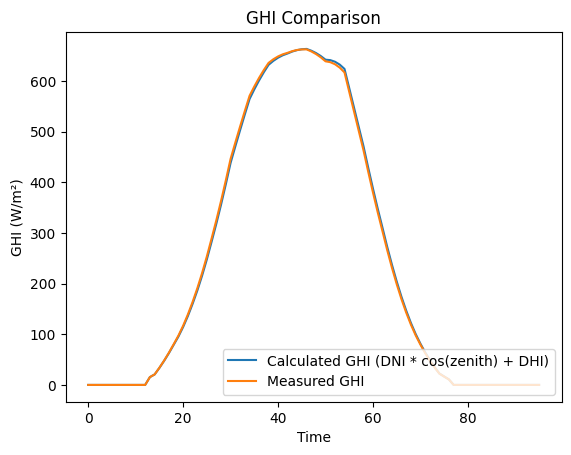

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cos(ds[idx][0]["solar_zenith"]) * ds[idx][0]["dni"] + ds[idx][0]["dhi"], label="Calculated GHI (DNI * cos(zenith) + DHI)")
plt.plot(ds[idx][0]["ghi"], label="Measured GHI")
#plt.plot(ds[idx][0]["dhi"], label="Measured DHI")
#plt.plot(ds[idx][0]["dni"], label="Measured DNI")
plt.legend(loc="lower right")
plt.xlabel("Time")
plt.ylabel("GHI (W/m²)")
plt.title("GHI Comparison")
plt.show()

In [24]:
import numpy as np
from tqdm import tqdm

dhi_avg = torch.zeros(96)
ghi_avg = torch.zeros(96)
dni_avg = torch.zeros(96)

for i in tqdm(range(len(ds))):
    dhi_avg += ds[i][0]["dhi"]
    ghi_avg += ds[i][0]["ghi"]
    dni_avg += ds[i][0]["dni"]

dhi_avg /= len(ds)
ghi_avg /= len(ds)
dni_avg /= len(ds)

100%|██████████| 12295/12295 [09:28<00:00, 21.63it/s]


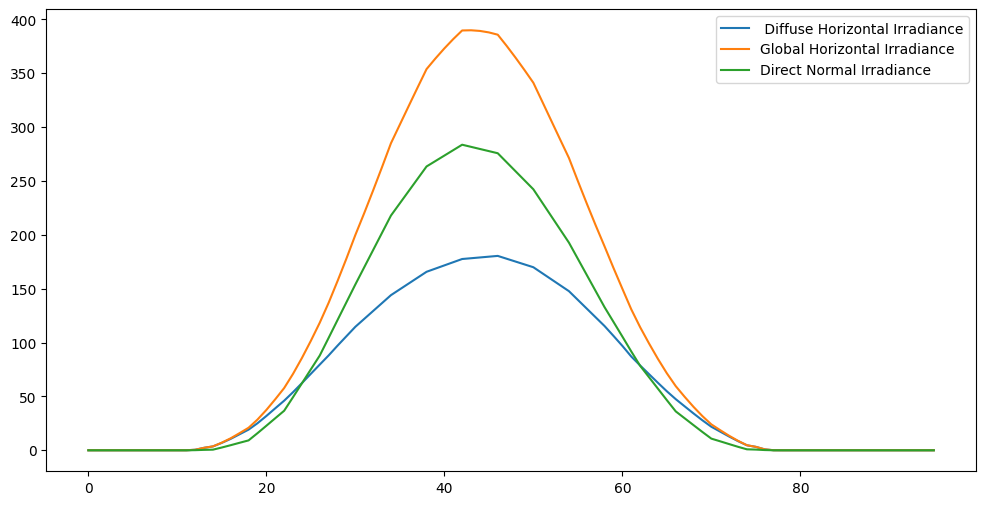

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(dhi_avg)
plt.plot(ghi_avg)
plt.plot(dni_avg)
plt.legend([" Diffuse Horizontal Irradiance", "Global Horizontal Irradiance", "Direct Normal Irradiance"])

Text(0.5, 1.0, 'Austria 96241: 2023-06-27')

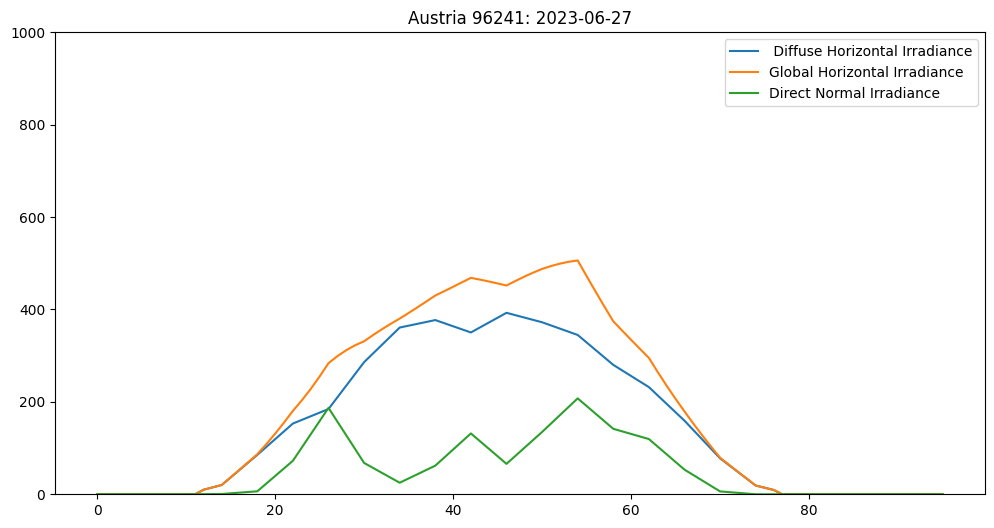

In [23]:
idx = 1200

plt.figure(figsize=(12, 6))
plt.plot(ds[idx][0]["dhi"])
plt.plot(ds[idx][0]["ghi"])
plt.plot(ds[idx][0]["dni"])
plt.legend([" Diffuse Horizontal Irradiance", "Global Horizontal Irradiance", "Direct Normal Irradiance"])

plt.ylim(0, 1000)

plt.title(f"{ds[idx][2]['country']} {ds[idx][2]['installation']}: {ds[idx][2]['date']}")

In [11]:
x, y, info = ds[idx]

for key in x:
    x[key] = x[key].unsqueeze(0)
for key in info:
    if not isinstance(info[key], str):
        info[key] = torch.tensor(info[key]).unsqueeze(0)

out, misc = model_fit.model(x, info)

/tmp/ipykernel_485058/153856408.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  info[key] = torch.tensor(info[key]).unsqueeze(0)


Text(0.5, 1.0, 'Austria 46021: 2023-12-28')

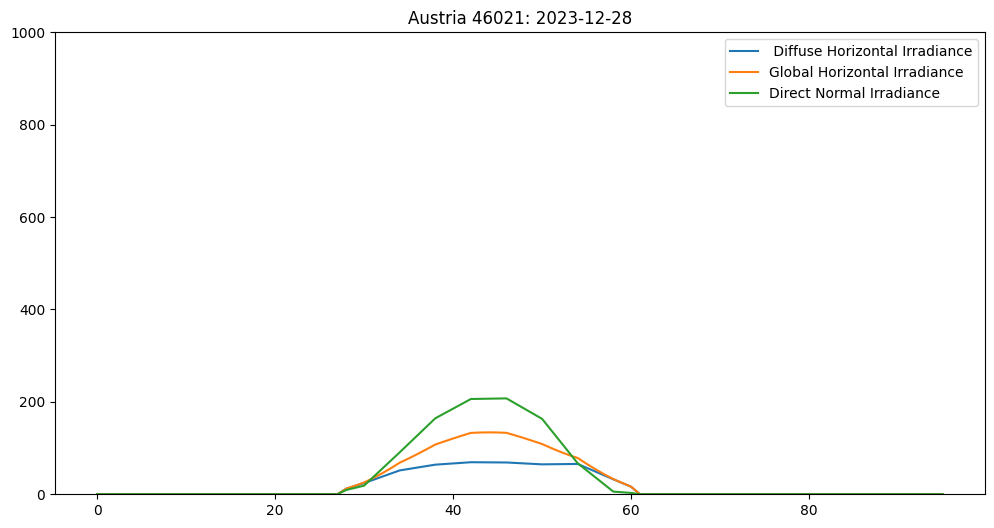

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ds[idx][0]["dhi"])
plt.plot(ds[idx][0]["ghi"])
plt.plot(ds[idx][0]["dni"])

plt.legend([" Diffuse Horizontal Irradiance", "Global Horizontal Irradiance", "Direct Normal Irradiance"])

plt.ylim(0, 1000)

plt.title(f"{ds[idx][2]['country']} {ds[idx][2]['installation']}: {ds[idx][2]['date']}")

Text(0.5, 1.0, 'Austria 46021: 2023-12-28')

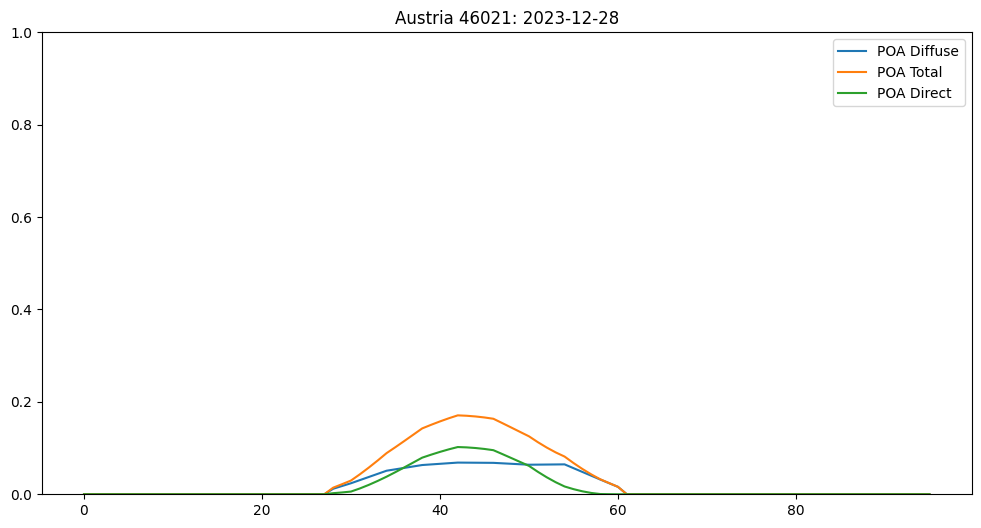

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(misc["poa_diffuse"].detach().numpy()[0])
plt.plot(misc["s"].detach().numpy()[0])
plt.plot(misc["poa_direct"].detach().numpy()[0])

plt.legend(["POA Diffuse", "POA Total", "POA Direct"])

plt.ylim(0, 1)

plt.title(f"{ds[idx][2]['country']} {ds[idx][2]['installation']}: {ds[idx][2]['date']}")